# 05 · What to control for — and what NOT to (pathmc)

**The business decision behind the statistics.** Every effect estimate in every other notebook depends on
a choice made *before* any model runs: **which variables to control for** (put in the model / adjust for).
Get it wrong and the number is biased no matter how fancy the estimator. The instinct "throw in every
column we have" is actively dangerous. This is the notebook that lets you tell a skeptical CMO *exactly why*
you controlled for what you did.

### The four roles a variable can play — and the rule for each

To "**control for**" (equivalently *adjust for*, *condition on*) a variable $W$ means to hold it fixed when
comparing treated vs untreated — e.g. by including it in the regression. Whether that helps or hurts depends
entirely on $W$'s causal role between treatment $T$ and outcome $Y$:

- **Confounder** — a common cause of *both* $T$ and $Y$ (e.g. customer loyalty drives both who gets emailed
  and how much they spend). It opens a spurious "backdoor" path $T \leftarrow W \rightarrow Y$. → **Control
  for it.** Failing to is the classic omitted-variable bias.
- **Mediator** — a variable *on the causal path* $T \rightarrow W \rightarrow Y$ (the effect flows through
  it). → **Do NOT control for it** — you'd subtract out part of the very effect you're trying to measure.
- **Collider** — a common *effect* of $T$ and $Y$ ($T \rightarrow W \leftarrow Y$). Conditioning on a
  collider *opens* a path that was closed, **manufacturing** a correlation that isn't causal. → **Do NOT.**
- **M-bias collider** — a *pre-treatment* variable that is a collider between two hidden causes. → **Do NOT**
  — proof that "just control for everything measured before treatment" is wrong.

The tool that decides this formally is the **backdoor criterion** on the **DAG** (the causal graph): a valid
**adjustment set** is any set of variables that blocks every backdoor path from $T$ to $Y$ *without*
including a mediator or a descendant of $T$. `pathmc` reads the graph and enumerates the valid sets for us.

### What this notebook does

(a) a **gallery** of the four structures with the correct action — and, right after it, a working
simulation for the two that usually stay pictures (mediator over-control and M-bias); (b) we formalize
d-separation and the backdoor criterion, apply them **by hand**, and only then let `pathmc` enumerate the
admissible adjustment set and flag colliders straight from the DAG; (c) we show the bias of each wrong
choice **in euros** — predicted from the graph first, confirmed in simulation second, including the
disguised version everybody commits (filtering to responders); (d) we bound the residual risk from an
*unobserved* confounder with a sensitivity contour and an **E-value** (the minimum confounder strength
that could explain the effect away), read the full **posterior** of the effect, and close with real data
(LaLonde), a practitioner's covariate checklist and a one-paragraph decision memo.

It follows the cookbook's standard **7-step arc**, with **identification** (which variables make the effect recoverable) — not estimation —
as the whole point. That claim is put on trial twice: **Step 0** runs the same plain OLS under the naive and
the backdoor-adjusted control sets (the estimator is held fixed; only the DAG's advice changes, and the
answer moves by €3), and **5x** runs the same Bayesian posterior under the right and the wrong adjustment
sets (the identification is what changes, and the *decision* flips). The estimator is never the thing that
saves you.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import logging, pymc
logging.getLogger("pymc").setLevel(logging.CRITICAL + 1)  # SamplerWarnings log at ERROR — mute them all
import pathmc
from cmp import dgp, estimators as est, metrics, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
FIT = dict(draws=400, tune=400, chains=2) if FAST else dict(draws=1500, tune=1500, chains=4)
SEED = 17

## 1b · The four structures — a control-or-not gallery

Every "should I control for W?" question reduces to *what role W plays* between treatment T and
outcome Y:


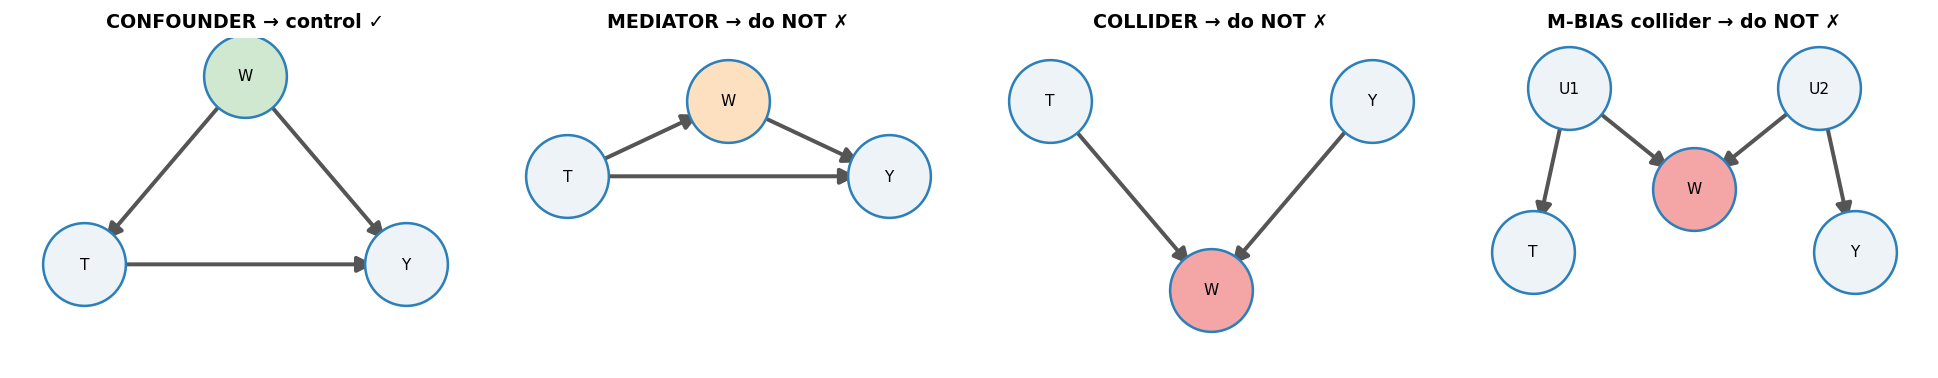

In [2]:
fig, ax = plt.subplots(1, 4, figsize=(15, 3.0))
plots.draw_dag(ax[0], {"W":(0.5,1.0),"T":(0.05,0.25),"Y":(0.95,0.25)},
    [("W","T"),("W","Y"),("T","Y")], node_colors={"W":"#cfe8cf"}, title="CONFOUNDER → control ✓")
plots.draw_dag(ax[1], {"T":(0.05,0.6),"W":(0.5,0.9),"Y":(0.95,0.6)},
    [("T","W"),("W","Y"),("T","Y")], node_colors={"W":"#fde0c0"}, title="MEDIATOR → do NOT ✗")
plots.draw_dag(ax[2], {"T":(0.05,0.9),"Y":(0.95,0.9),"W":(0.5,0.15)},
    [("T","W"),("Y","W")], node_colors={"W":"#f4a6a6"}, title="COLLIDER → do NOT ✗")
plots.draw_dag(ax[3], {"U1":(0.15,0.95),"U2":(0.85,0.95),"T":(0.05,0.3),"Y":(0.95,0.3),"W":(0.5,0.55)},
    [("U1","T"),("U1","W"),("U2","W"),("U2","Y")], node_colors={"W":"#f4a6a6"}, title="M-BIAS collider → do NOT ✗")
fig.tight_layout()

- **Confounder** (common cause of T and Y): **control** — it opens a backdoor path.
- **Mediator** (on the causal path T→W→Y): **do not** — you'd remove part of the effect you want.
- **Collider** (common effect of T and Y): **do not** — conditioning *opens* a spurious path.
- **M-bias collider** (pre-treatment, common effect of two latents that separately cause T and Y):
  **do not** — even a *pre-treatment* variable can be a trap. "Adjust for everything pre-treatment"
  is wrong.


## 1c · The other two traps, with data — the mediator first

The gallery's confounder and collider get a full simulation in §2–5. The other two panels are the ones
that usually stay pictures — so before moving on, we simulate **both** in miniature, and every rule in the
gallery has a number attached.

**Trap 1 — the mediator.** A discount email lifts spend two ways: directly (the customer redeems from the
email itself) and *indirectly*, by pulling the customer to the site where they spend more. Site visits sit
*on the causal path* — a **mediator**. We deliberately **randomize** $T$ (a coin-flip email) so there is no
confounding anywhere: whatever goes wrong below is purely the control choice. The data-generating model,
with $\sigma(z) = 1/(1+e^{-z})$:

$$
\begin{aligned}
T = \text{email} &\sim \text{Bernoulli}(0.5) &&\text{(randomized — no confounding by design)}\\[2pt]
M = \text{visited} &\sim \text{Bernoulli}\big(\sigma(-0.5 + 1.5\,T)\big) &&\text{(the email drives site visits)}\\[2pt]
Y = \text{spend} &= 20 + 3\,T + 8\,M + \varepsilon, \qquad \varepsilon \sim \mathcal N(0,\, 4^{2}) &&\text{(spend responds to both)}
\end{aligned}
$$

The number the CMO is asking for — "what does one email add to spend, *all channels included*?" — is the
**total effect**, which splits into a direct and an indirect (through-visits) piece:

$$
\tau_{\text{total}}
= \underbrace{3}_{\text{direct}}
+ \underbrace{8\,\big[P(M{=}1 \mid T{=}1) - P(M{=}1 \mid T{=}0)\big]}_{\text{indirect, via visits}}
= 3 + 8\,\big[\sigma(1.0) - \sigma(-0.5)\big] \approx 5.8 .
$$

Two regressions on the same simulated data — one with no controls, one "helpfully" controlling for
`visited`:

In [3]:
# --- Mediator: controlling for a variable ON the causal path changes the question ---
sig = lambda z: 1.0 / (1.0 + np.exp(-z))
N_MINI = 20_000                                   # plain numpy OLS — instant, no FAST gating needed
rng = np.random.default_rng(23)
T_m = (rng.uniform(size=N_MINI) < 0.5).astype(float)                       # randomized email
visited = (rng.uniform(size=N_MINI) < sig(-0.5 + 1.5 * T_m)).astype(float)
dmed = pd.DataFrame({"email": T_m, "visited": visited,
                     "spend": 20 + 3 * T_m + 8 * visited + rng.normal(0, 4, N_MINI)})

def ols_on(d, controls, treat="email", outcome="spend"):
    X = np.column_stack([np.ones(len(d)), d[treat].values] + [d[c].values for c in controls])
    return np.linalg.lstsq(X, d[outcome].values, rcond=None)[0][1]

dM = visited[T_m == 1].mean() - visited[T_m == 0].mean()      # how much the email moves visit probability
print(f"TRUTHS   direct = €3.00  ·  total = 3 + 8·ΔM = 3 + 8·{dM:.3f} ≈ €{3 + 8 * dM:.2f}")
print(f"no controls           : €{ols_on(dmed, []):.2f}   → the TOTAL effect (what the CMO asked for)")
print(f"controlling 'visited' : €{ols_on(dmed, ['visited']):.2f}   → only the DIRECT effect — the €{8 * dM:.2f} "
      "that flows through visits is silently subtracted")

TRUTHS   direct = €3.00  ·  total = 3 + 8·ΔM = 3 + 8·0.348 ≈ €5.78
no controls           : €5.69   → the TOTAL effect (what the CMO asked for)
controlling 'visited' : €2.92   → only the DIRECT effect — the €2.78 that flows through visits is silently subtracted


**Read-out (mediator).** With $T$ randomized, the no-controls regression is unbiased for the total effect
— and lands on it (up to sampling noise around the ≈ €5.8 truth). Adding `visited` does not "improve
precision"; it **changes the estimand** (the quantity you are actually estimating — here shifting the target from the total effect to the direct effect): the coefficient now answers *"what would the email do if we could
freeze site visits?"* — the direct effect (≈ €3), not the number the CMO asked about. Sometimes that split
is exactly what you want — notebook 04 builds the total/direct/indirect machinery deliberately. The sin is
not computing a direct effect; it is computing one *by accident* and calling it the campaign's lift: an
analyst who controls for post-send engagement quietly books only the fraction of the lift that bypasses
the site.

**Trap 2 — M-bias: the pre-treatment variable that is still a collider.** Two customer traits we never
observe: *deal-proneness* $U_1$ (drives historical coupon usage **and** who the targeting model emails) and
*brand affinity* $U_2$ (drives historical coupon usage **and** spend). Last year's coupon-redemption count
$W$ is measured **before** the send and correlates with both treatment and outcome — by every heuristic it
"looks like" a confounder. The data-generating model (exactly the gallery's fourth panel):

$$
\begin{aligned}
U_1,\, U_2 &\sim \mathcal N(0,1)\ \text{(unobserved)}, &
W &= U_1 + U_2 + \nu,\ \ \nu \sim \mathcal N(0,1),\\[3pt]
T &\sim \text{Bernoulli}\big(\sigma(0.8\,U_1)\big), &
Y &= 20 + 6\,T + 3\,U_2 + \varepsilon,\ \ \varepsilon \sim \mathcal N(0,\, 4^{2}).
\end{aligned}
$$

Trace the only indirect path: $T \leftarrow U_1 \to W \leftarrow U_2 \to Y$. It contains a **collider at
$W$** (two arrowheads meet there), so it is **already blocked** — §3 formalizes this rule. There is *no
open backdoor*: the naive estimate is unbiased before we touch anything. Conditioning on $W$ *opens* the
path. **Why does holding `coupon_history` fixed hurt?** $W \approx U_1 + U_2$, so *once you know $W$*, a high $U_1$ implies a low $U_2$ (they must sum to the observed $W$) — conditioning on the shared effect $W$ makes the two hidden causes correlated. That freshly-manufactured $U_1$–$U_2$ link splices $T \leftarrow U_1$ onto $U_2 \to Y$, opening a $T$–$Y$ path that was shut. This is 'explaining away' (§3) with one extra hop through the latents:

In [4]:
# --- M-bias: a PRE-treatment variable that poisons the estimate when controlled ---
rng = np.random.default_rng(29)
U1, U2 = rng.normal(0, 1, N_MINI), rng.normal(0, 1, N_MINI)
T_b = (rng.uniform(size=N_MINI) < sig(0.8 * U1)).astype(float)
dmb = pd.DataFrame({"email": T_b,
                    "coupon_history": U1 + U2 + rng.normal(0, 1, N_MINI),   # measured PRE-treatment
                    "spend": 20 + 6 * T_b + 3 * U2 + rng.normal(0, 4, N_MINI)})
print(f"TRUE effect €6.00  ·  corr(coupon_history, email) = {dmb.coupon_history.corr(dmb.email):+.2f}, "
      f"corr(coupon_history, spend) = {dmb.coupon_history.corr(dmb.spend):+.2f}  → 'looks like' a confounder")
print(f"no controls                : €{ols_on(dmb, []):.2f}   → already unbiased (the collider at W keeps the path shut)")
print(f"controlling coupon_history : €{ols_on(dmb, ['coupon_history']):.2f}   → conditioning OPENED the path — "
      "bias from a 'safe' pre-treatment control")

TRUE effect €6.00  ·  corr(coupon_history, email) = +0.21, corr(coupon_history, spend) = +0.41  → 'looks like' a confounder
no controls                : €5.99   → already unbiased (the collider at W keeps the path shut)
controlling coupon_history : €5.22   → conditioning OPENED the path — bias from a 'safe' pre-treatment control


**Read-out (M-bias).** The naive estimate was already right; adding the pre-treatment,
correlated-with-everything covariate moved it *away* from the €6 truth by the better part of a euro. This
is the counterexample that kills the most common heuristic in applied work — **"control for everything
measured before treatment."** A timestamp is not a criterion.

Two honest caveats before anyone panics and deletes covariates. First, magnitude: pure M-bias is usually
**modest** next to confounder bias (the theoretical result that M-bias is typically small-magnitude — Ding & Miratrix 2015) — compare the sub-€1 shift here with the +€3.5
confounding bias coming in §4. Second, the common real-world tangle: when a variable is plausibly *both* a
genuine confounder **and** an M-collider, adjusting is usually the lesser evil. The point is not "never
control pre-treatment variables"; it is that **the decision comes from the graph, not the timestamp** —
which is exactly why the rest of this notebook makes the graph explicit and lets *it* choose.

## 2 · Simulate a ground truth

`email → spend` with a **true effect of €6**. Around it: **`loyalty`** is a **confounder**
(drives both email and spend → must control); **`responded`** is a **collider** (caused by both
email and spend → tempting but poisonous); **`opened_email`** is a post-treatment descendant.

**The data-generating model** — exactly what `dgp.dag_control_demo` implements (defaults & seed in
`src/cmp/dgp.py`). Loyalty $L \sim \mathcal N(0,1)$; an **unobserved** engagement trait
$G \sim \mathcal N(0,1)$; $\sigma(z) = 1/(1+e^{-z})$:

$$
\begin{aligned}
T = \text{email} &\sim \text{Bernoulli}\big(\sigma(0.8\,L)\big)
  &&\text{(assignment is confounded by loyalty)}\\[2pt]
Y = \text{spend} &= 20 + 5\,L + 6\,T + 3\,G + \varepsilon, \qquad \varepsilon \sim \mathcal N(0,\, 4^{2})
  &&\text{(true ATE — average treatment effect: the 6)}\\[2pt]
\text{opened\_email} &\sim \text{Bernoulli}\big(\sigma(1.5\,T + 0.7\,G)\big)
  &&(T \to \text{opened} \leftarrow G \to Y)\\[2pt]
\text{responded} &\sim \text{Bernoulli}\big(\sigma(1.2\,T + 0.05\,(Y - \bar Y))\big)
  &&(T \to \text{responded} \leftarrow Y).
\end{aligned}
$$

$L$ appears in both the treatment and the outcome equations — the backdoor that must be closed.
Neither `opened_email` nor `responded` appears in the spend equation, so controlling for them can
only manufacture bias: `responded` is the textbook collider (caused by $T$ and $Y$ directly), while
`opened_email` is the *subtler* trap — its collider path runs through the **unobserved** $G$, which
is why a DAG drawn without $G$ cannot warn you (the falsification section below catches it from data).


In [5]:
df, true_ate = dgp.dag_control_demo(n=2000, seed=SEED)
print(f"TRUE effect of email on spend = €{true_ate:.1f}")
df.head()

TRUE effect of email on spend = €6.0


,email,loyalty,opened_email,responded,spend
0,1.0,1.101262,1.0,0.0,27.705363
1,0.0,0.338431,0.0,0.0,17.425501
2,0.0,-0.539972,0.0,0.0,9.602566
3,0.0,-1.260242,0.0,0.0,5.056443
4,1.0,-1.894621,0.0,0.0,7.175152


## 3 · Identify — let the DAG choose the adjustment set

So far "blocking a path" has been a metaphor. Before handing the graph to `pathmc`, we make it a **rule you
can run by hand** — because the library below does nothing more than apply this rule exhaustively, and you
should be able to audit it.

**Rule 1 — when is a path blocked? (the d-separation rules).** A *path* between $T$ and $Y$ is any sequence
of edges connecting them, arrows pointing either way. Given a candidate control set $Z$, a path is
**blocked** iff it contains at least one of:

$$
\begin{gathered}
\underbrace{A \to B \to C \ \ \text{or}\ \ A \leftarrow B \to C \quad \text{with } B \in Z}_{\text{chain or fork: conditioning on the middle node closes it}}
\\[6pt]
\text{or}
\\[6pt]
\underbrace{A \to B \leftarrow C \quad \text{with } B \notin Z \text{ and no descendant of } B \text{ in } Z}_{\text{collider: closed by default — conditioning on } B \text{ (or its descendants) opens it}}
\end{gathered}
$$

where a *descendant* of $B$ is any variable reachable from $B$ by following arrows forward. In words:
conditioning on a **common cause** (fork) or an intermediate step (chain) removes the association that node
transmits — compare customers at the *same* loyalty and the "loyal people get emailed and spend more anyway"
signal disappears. Conditioning on a **common effect** (collider) does the reverse — it *creates* an
association that was never there. The intuition is **explaining away**: among customers who responded,
seeing high spend makes the email a *less necessary* explanation for the response, so email and spend
become negatively related inside that group even if they are independent overall.

**Rule 2 — the backdoor criterion.** A set $Z$ is an **admissible adjustment set** for the effect of $T$ on
$Y$ iff

$$
\begin{gathered}
\text{(a) no element of } Z \text{ is a descendant of } T,
\quad\text{and}\\[3pt]
\text{(b) } Z \text{ blocks every path from } T \text{ to } Y \text{ that starts with an arrow into } T .
\end{gathered}
$$

Paths starting with an arrow *into* $T$ are the **backdoor paths** — the routes along which "who got
treated" leaks information about the outcome. When (a) and (b) hold, the interventional quantity is
recovered by the **adjustment formula**

$$
P\big(Y \mid do(T{=}t)\big) \;=\; \sum_{z} P\big(Y \mid T{=}t,\, Z{=}z\big)\; P(z),
$$

where $do(T{=}t)$ means "set $T$ by intervention" (everyone gets the email) rather than "observe $T{=}t$"
(the loyal self-select into it). Plain reading: *compare treated vs untreated within look-alike strata of
$Z$, then average the strata back together with population weights.* Every regression adjustment in this
notebook is a linear-model shortcut for that formula.

**Run the algorithm by hand on our graph** (the one declared to `pathmc` below). Enumerate every path from
`email` to `spend`:

- `email → spend` — the causal path we are estimating. Leave it alone (blocking it, e.g. with a mediator,
  is §1c's trap);
- `email ← loyalty → spend` — starts with an arrow into `email` ⇒ a **backdoor**, open by default at the
  fork `loyalty` ⇒ any admissible $Z$ must contain `loyalty`;
- `email → responded ← spend` — a **collider** at `responded` ⇒ already blocked; putting `responded` in $Z$
  would *open* it (and `responded` is a descendant of $T$, failing condition (a) twice over);
- `email → opened_email` — a dead end in the *declared* graph (no arrow onward to `spend`), so it lies on
  no $T$–$Y$ path at all. Remember this one: it is exactly the blind spot the falsification section below
  exposes.

So $Z = \{\text{loyalty}\}$ is admissible (and minimal). That enumeration is **all** that
`m.adjustment_sets` does — read its output below and check it against your own answer.

**One more requirement the graph cannot show — positivity.** The adjustment formula only averages strata
where *both* arms exist: identification also needs $0 < P(T{=}1 \mid Z{=}z) < 1$ for every stratum $z$
(**overlap**). Here it holds by construction — $\sigma(0.8\,L) \in (0,1)$ for every finite loyalty — but
with a high-dimensional $Z$ it fails silently; nb01's Step-4 propensity (the modelled $P(T{=}1\mid Z)$) histogram
(`est.propensity_scores` + `plots.overlap_plot`) is the standard check. Identification has two clauses —
**no open backdoors *and* positivity** — not one.

**Reading the `pathmc` spec below.** Each line is *node ~ its direct causes*, not a regression: `email ~ loyalty` declares the edge loyalty → email (loyalty is a cause of who gets emailed), not a regression of email on loyalty. So this block is exactly the four-node DAG we just enumerated by hand.


In [6]:
spec = '''
email        ~ b1*loyalty
opened_email ~ b2*email
responded    ~ b3*email + b4*spend
spend        ~ b5*email + b6*loyalty
'''
m = pathmc.model(spec, data=df)
print("Admissible adjustment set(s) for email → spend:", m.adjustment_sets("email", "spend"))
print("Identifiable:", m.is_identifiable("email", "spend"))
print()
for cand in [{"loyalty"}, {"loyalty","responded"}, {"loyalty","opened_email"}, set()]:
    warns = m.collider_warnings(cand, "email", "spend")
    print(f"control for {cand or '{}'}:  " + ("; ".join(warns) if warns else "OK — no collider opened"))

Admissible adjustment set(s) for email → spend: [{'loyalty'}]
Identifiable: True

control for {'loyalty'}:  OK — no collider opened
control for {'loyalty', 'responded'}:  'responded' is a collider between 'email' and 'spend'. Conditioning on it may open a spurious path and introduce bias.
control for {'loyalty', 'opened_email'}:  OK — no collider opened
control for {}:  OK — no collider opened


(Read the printout above as the machine doing the reasoning: it names `{loyalty}` as the one adjustment
set that closes the backdoor, confirms the effect is identifiable, and — critically — *warns* when a
candidate set includes `responded`, because that variable is a collider. This is the DAG logic from the
intro, applied automatically.)

## Step 0 · The classical read (no likelihood, no priors, no sampler)

Before any Bayesian machinery, ask what a competent analyst does here **without** it. In most of this
cookbook that question opens a detour. Here it opens the *whole argument*, because the estimator this
notebook needs is the plainest one there is: **ordinary least squares**, spend regressed on email plus an
adjustment set $Z$,

$$\text{spend}_i \;=\; \beta_0 \;+\; \tau\,\text{email}_i \;+\; \gamma^\top Z_i \;+\; \varepsilon_i ,$$

with $\hat\tau$, the coefficient on `email`, as **the estimand** — the €-per-email ATE §3 just wrote down,
identified by the backdoor criterion under exactly the assumptions §3 listed (no open backdoor once $Z$ is
held fixed, plus positivity). No likelihood, no prior, no sampler; a point estimate and a confidence
interval, in milliseconds.

**Two fits, one estimator, and the only thing that changes is $Z$.**

- $Z = \varnothing$ — the **naive** read. What you get by regressing spend on email and nothing else: the
  number a dashboard hands you.
- $Z = \{\text{loyalty}\}$ — the **backdoor-adjusted** read. The set `pathmc` endorsed above, and the one we
  enumerated by hand.

Both are OLS. Both are competently executed. One is right and one is wrong, and *the estimator has no idea
which*.

**The covariance choice, and why it is HC1 here.** An interval on a wrong standard error is a confident
lie, so the covariance assumption has to be argued, not defaulted. Our rows are **2,000 independent
customers** measured **once**: there is no panel to cluster on (each customer contributes one row, so
"within-cluster" correlation has nothing to correlate) and no time index to apply a HAC correction to. What
remains is the cross-sectional worry — **heteroskedasticity**, i.e. residual variance that differs across
customers (say, spend being more volatile among the loyal). `HC1` (the Huber–White sandwich with a small-sample
correction) is robust to exactly that and is the honest cross-sectional default. Whether it *matters* on this
data is an empirical question, not a rhetorical one, so the cell below prints a **Breusch–Pagan test** (its
null is homoskedasticity) and the HC1-to-iid standard-error ratio, and we read the verdict off the print-out
rather than assuming it.

In [7]:
from cmp import classical as cl
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan

F_NAIVE, F_ADJ = "spend ~ email", "spend ~ email + loyalty"      # the ONLY difference is Z
naive_cl = cl.ols(df, F_NAIVE, target="email", cov="HC1", name="Z = {}        (naive)")
adj_cl   = cl.ols(df, F_ADJ,   target="email", cov="HC1", name="Z = {loyalty} (adjusted)")

# Is HC1 doing any work here, or just buying insurance? Test, do not assume.
_m = smf.ols(F_ADJ, data=df).fit()
bp_p = float(het_breuschpagan(_m.resid, _m.model.exog)[1])
adj_iid = cl.ols(df, F_ADJ, target="email", cov="nonrobust")

print(f"THE ESTIMAND — the €-per-email ATE: the `email` coefficient of an OLS")
print(f"fit on {naive_cl.n:,} customers. Same estimator, same data, same target.")
print(f"Only the adjustment set Z changes.   [{adj_cl.cov}]\n")
for r in (naive_cl, adj_cl):
    print(f"  {r.name:26s} €{r.estimate:5.2f}  [90% CI {r.ci[0]:5.2f}, {r.ci[1]:5.2f}]  SE {r.se:.2f}")
print(f"\n  Breusch-Pagan p = {bp_p:.2f} (null: errors are homoskedastic)")
print(f"  SE(HC1) / SE(iid) = {adj_cl.se / adj_iid.se:.3f}")

print(f"\nGRADE against the planted truth (€{true_ate:.0f} — a simulation-only luxury):")
for r in (naive_cl, adj_cl):
    inside = "INSIDE" if r.ci[0] <= true_ate <= r.ci[1] else "OUTSIDE"
    print(f"  {r.name:26s} error {r.estimate - true_ate:+5.2f}   CI width €{r.ci[1] - r.ci[0]:.2f}"
          f"   truth {inside}")
print(f"\n{adj_cl.cannot_say()}")

THE ESTIMAND — the €-per-email ATE: the `email` coefficient of an OLS
fit on 2,000 customers. Same estimator, same data, same target.
Only the adjustment set Z changes.   [HC1 heteroskedasticity-robust]

  Z = {}        (naive)      € 9.45  [90% CI  8.94,  9.95]  SE 0.31
  Z = {loyalty} (adjusted)   € 6.09  [90% CI  5.69,  6.48]  SE 0.24

  Breusch-Pagan p = 0.94 (null: errors are homoskedastic)
  SE(HC1) / SE(iid) = 1.001

GRADE against the planted truth (€6 — a simulation-only luxury):
  Z = {}        (naive)      error +3.45   CI width €1.01   truth OUTSIDE
  Z = {loyalty} (adjusted)   error +0.09   CI width €0.79   truth INSIDE

What this 90% confidence interval does NOT say: that there is a 90% probability the true effect lies inside it. It is a property of the *procedure* — 90% of intervals built this way would cover the truth across repeated samples. This interval either contains the truth or it does not. To get a probability *about the effect itself* — the thing a go/no-go rule

**Read-out — the DAG did the work; the estimator merely executed it.**

The adjusted fit lands on the planted €6 and its 90% interval covers it. The naive fit does not — and look
at *how* it fails. It is not vague, hedged or evasive: its interval is of the same order of width as the
adjusted one (the print-out gives both — roughly a euro wide), and it sits **several euros** away from
the truth, which it excludes outright.
That is the definition of **confidently wrong**: the omitted-variable bias from leaving `loyalty` out is a
*fixed offset*, and a confidence interval quantifies **sampling noise around whatever the estimator
converges to** — never the distance between that limit and the truth. Precision is not validity, and no
standard error, however robust, will tell you which of these two numbers to believe.

Note also what HC1 bought: the Breusch–Pagan test does not reject homoskedasticity and the HC1 standard
error is within a fraction of a percent of the iid one — on *this* DGP the noise really is constant-variance
Gaussian, so the robust sandwich changed nothing. We keep it anyway, and say so plainly: you cannot know
that in advance without checking, HC1 costs nothing when errors are homoskedastic, and it saves you when
they are not. Insurance that turns out unnecessary was still worth buying.

**Now the sentence this whole notebook exists to earn.** The gap between those two lines was produced by a
choice made *before* any estimator ran — which variables to hold fixed — and it is the entire difference
between a defensible number and a €3-per-customer fantasy. **No amount of Bayesian machinery closes that
gap.** A prior cannot tell you that `loyalty` is a confounder; a posterior cannot detect that a backdoor is
open; MCMC will converge beautifully on the wrong estimand. *The DAG does the causal work; the estimator
only executes it.* §4–5 now runs the same OLS across five adjustment sets to price that claim, and **5x**
holds the classical answer against the Bayesian posterior on the same set, so you can see exactly what the
machinery adds — and what it cannot.

Finally, the boundary printed above, which is the same in every notebook of this cookbook: a 90% confidence
interval is a property of the *procedure*, not a probability about the effect. The go/no-go rule §6 actually
uses — $P(\text{lift} > \text{cost}) \ge 0.9$ — is a statement *about the effect itself*, and that sentence
has no frequentist translation. It needs a posterior. That, and not a better point estimate, is what §4's
Bayesian layer is for.

## 4–5 · Estimate & Validate — every control choice, in €

Now we make the abstract warnings concrete and expensive. We estimate the same email→spend effect **five
ways**, each time controlling for a different set of variables, and compare to the known true €6:

- **nothing** (naive) — leaves the loyalty confounding in, so it's biased *up*;
- **{loyalty}** — the DAG-endorsed set; should land on €6;
- **{loyalty, responded}** — adds a *collider*, which opens a spurious path;
- **{loyalty, opened}** — adds a *post-treatment descendant*, another no-no;
- **everything** — the "throw it all in" instinct, which stacks the errors.

The punchline is that **the sign and rough size of each bias is predictable from the graph *plus the signs of
its edges* *before* you run anything** (here loyalty raises both emailing and spend): omitting a confounder biases up; conditioning on a collider or a post-treatment variable biases
in the direction of the association it induces. Controlling for more is *not* safer.

**The fitted model, in symbols** — the same OLS regression five times, differing only in the
control set $W$:

$$
\text{spend}_i = \beta_0 + \hat\tau\, \text{email}_i + \gamma^\top W_i + \varepsilon_i,
$$

reading off $\hat\tau$ for each choice of $W \in \big\{\varnothing,\; \{L\},\;
\{L, \text{responded}\},\; \{L, \text{opened}\},\; \{L, \text{responded}, \text{opened}\}\big\}$.
Same estimator, same data — *only the adjustment set changes*, so every difference between the bars
below is pure identification, not modeling. This is **Step 0's fit, run five times**: the same `cl.ols`
call, the same `email` coefficient, the same HC1 covariance (argued above: independent customers, one row
each, possible heteroskedasticity), so every bar carries a 90% confidence interval and no bar is a bare
point estimate. Watch what the intervals do *not* do: they are all of similar width, and none of them
flags the bar it belongs to as biased.

OLS `email` coefficient · HC1 heteroskedasticity-robust · n = 2,000

  adjustment set                €   90% CI           error  width   covers €6?
  naive (nothing)            9.45   [ 8.94,  9.95]  +3.45   1.01   NO
  {loyalty} ✓                6.09   [ 5.69,  6.48]  +0.09   0.79   yes
  {loyalty,responded} ✗      5.58   [ 5.15,  6.00]  -0.42   0.84   NO
  {loyalty,opened} ✗         5.45   [ 5.04,  5.85]  -0.55   0.81   NO
  everything ✗               4.97   [ 4.55,  5.40]  -1.03   0.84   NO

1/5 of the five 90% intervals cover the truth, and the widths span only €0.79–€1.01:
the wrong sets are not vaguer than the right one, they are just as precise — about a different number.


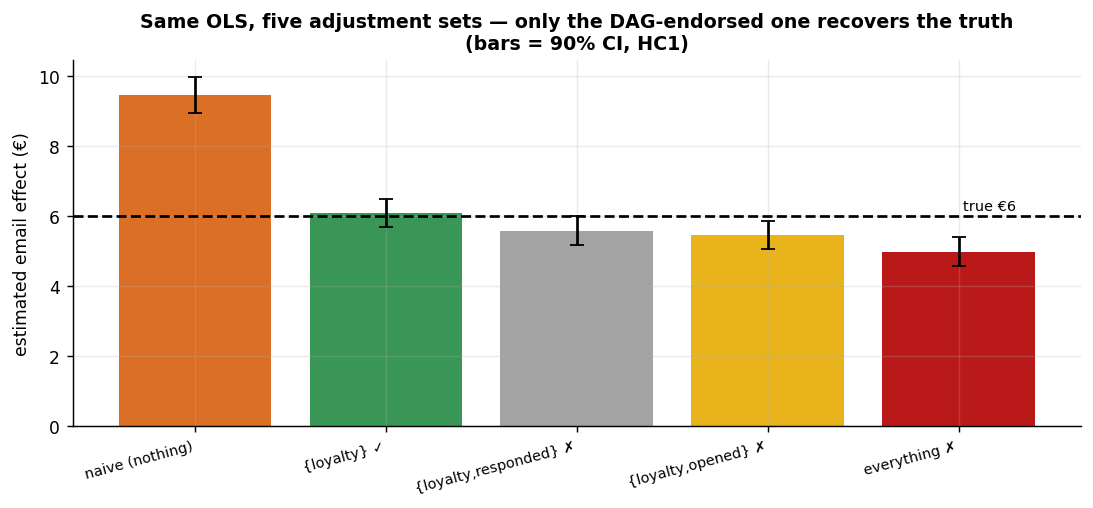

In [8]:
# The five adjustment sets — one cl.ols call each, HC1, 90% CIs. Identical estimator throughout.
choices = {
    "naive (nothing)": [], "{loyalty} ✓": ["loyalty"],
    "{loyalty,responded} ✗": ["loyalty","responded"],
    "{loyalty,opened} ✗": ["loyalty","opened_email"],
    "everything ✗": ["loyalty","responded","opened_email"],
}
def fit_set(controls, label):
    f = "spend ~ email" + "".join(f" + {c}" for c in controls)
    return cl.ols(df, f, target="email", cov="HC1", alpha=0.10, name=label)

bake = {k: fit_set(v, k) for k, v in choices.items()}
ests = {k: r.estimate for k, r in bake.items()}          # the point estimates, reused downstream
mid = np.array([r.estimate for r in bake.values()])
lo  = np.array([r.ci[0] for r in bake.values()]); hi = np.array([r.ci[1] for r in bake.values()])

fig, ax = plt.subplots(figsize=(8.5, 4.0))
cols = [plots.ORANGE, plots.GREEN, plots.GREY, plots.GOLD, "#b30000"]
ax.bar(range(len(bake)), mid, yerr=np.vstack([mid - lo, hi - mid]), capsize=4, color=cols, alpha=0.9)
ax.axhline(true_ate, color="k", ls="--"); ax.text(4.3, true_ate+0.15, f"true €{true_ate:.0f}", ha="right", fontsize=8)
ax.set_xticks(range(len(bake))); ax.set_xticklabels(list(bake), rotation=15, ha="right", fontsize=8)
ax.set_ylabel("estimated email effect (€)")
ax.set_title("Same OLS, five adjustment sets — only the DAG-endorsed one recovers the truth\n(bars = 90% CI, HC1)")
fig.tight_layout()

endorsed = bake["{loyalty} ✓"]
print(f"OLS `email` coefficient · {endorsed.cov} · n = {endorsed.n:,}\n")
print(f"  {'adjustment set':24s}{'€':>7}{'   90% CI':<18}{'error':>7}{'width':>7}   covers €{true_ate:.0f}?")
for k, r in bake.items():
    covers = "yes" if r.ci[0] <= true_ate <= r.ci[1] else "NO"
    print(f"  {k:24s}{r.estimate:7.2f}   [{r.ci[0]:5.2f}, {r.ci[1]:5.2f}]{r.estimate - true_ate:+7.2f}"
          f"{r.ci[1] - r.ci[0]:7.2f}   {covers}")
n_cov = sum(r.ci[0] <= true_ate <= r.ci[1] for r in bake.values())
print(f"\n{n_cov}/{len(bake)} of the five 90% intervals cover the truth, and the widths span only "
      f"€{(hi - lo).min():.2f}–€{(hi - lo).max():.2f}:\nthe wrong sets are not vaguer than the right one, "
      f"they are just as precise — about a different number.")

**How to read this.** Only the green bar — `{loyalty}`, the set the DAG endorsed — lands on the true €6, and
it is the only one whose interval covers it (the `covers €6?` column). The naive bar overshoots (confounding
left in); adding the collider `responded` or the hidden collider `opened_email` (see the falsification test
below) *pulls the estimate away* even though we already had the right confounder; and "everything" is the
worst of all.

Now read the **widths**, because that is where the lesson bites. Every interval is roughly the same size —
the wrong sets are not *hedging*, they are not *noisy*, they are not *flagged*. They are precise, and they
are precise about the wrong number. Four of these five fits are a confident lie, and nothing inside the
regression output — not the standard error, not the $R^2$, not the robust covariance we so carefully argued
for in Step 0 — distinguishes them from the fifth. The moral for a practitioner is blunt: **the model can't
tell you it's biased — the bars all look like plausible numbers, with plausible error bars.** The only
defence is choosing the control set from the causal graph *before* looking at the estimates, which is
precisely what makes the answer defensible to a skeptic.

### Depth check — predict the bars before running them

§4–5's preamble claimed the sign *and rough size* of each bias is readable off the graph. That deserves a
derivation, not an assertion. Both wrong directions follow from two pocket formulas.

**1 · Omitted confounder ⇒ omitted-variable bias (OVB).** Regress spend on email alone under the §2 DGP
($Y = 20 + 5L + 6T + 3G + \varepsilon$, with the engagement trait $G$ independent of $T$). The naive
coefficient converges to

$$
\hat\tau_{\text{naive}} \;\xrightarrow{\;p\;}\; \tau \;+\; \beta_L\,\big(\mathbb E[L \mid T{=}1] - \mathbb E[L \mid T{=}0]\big),
\qquad \beta_L = 5,
$$

the classic OVB formula specialized to a binary treatment: **bias = (effect of the omitted variable on the
outcome) × (its imbalance across arms)**. Both factors are positive here — loyalty raises spend
($\beta_L = 5 > 0$) and loyal customers get emailed more (positive imbalance) — so the graph plus edge
signs says *biased up*, and the DGP coefficients say *by how much*. The cell below computes the prediction
and holds it against the naive bar.

**2 · Conditioned collider ⇒ explaining-away, with a sign rule.** For a collider receiving
$C \leftarrow a\,T$ and $C \leftarrow b\,Y$, conditioning on $C$ induces a non-causal $T$–$Y$ association of
sign $-\,\mathrm{sign}(a\,b)$ — the minus sign is explaining-away made quantitative: if $T$ and $Y$ both *push $C$ up* ($a,b > 0$), then within a fixed-$C$ stratum a high $T$ must be offset by a low $Y$, so they read as negatively related. For `responded`, $a = 1.2 > 0$ and $b = 0.05 > 0$, so the induced association
is **negative** — the pocket rule: *both arrows into the collider positive ⇒ conditioning biases the
estimate down.* That is the direction of all three ✗ bars. (The M-bias example of §1c runs on the same
explaining-away algebra, just with one extra hop through the latents.)

In [9]:
# OVB check: predicted bias = beta_L × (loyalty imbalance across arms) — no refit needed
dL = df.loyalty[df.email == 1].mean() - df.loyalty[df.email == 0].mean()
pred_bias = 5.0 * dL
obs_bias = ests["naive (nothing)"] - true_ate
print(f"loyalty imbalance across arms      ΔL = {dL:+.3f}")
print(f"predicted naive bias    β_L·ΔL = 5 × {dL:.3f} = {pred_bias:+.2f}")
print(f"observed naive bias     (naive bar − truth)   = {obs_bias:+.2f}   → they agree to €{abs(pred_bias - obs_bias):.2f}")
err_resp, err_open, err_all = (ests[k] - true_ate
                               for k in ["{loyalty,responded} ✗", "{loyalty,opened} ✗", "everything ✗"])
print(f"\ncollider sign rule: a = +1.2, b = +0.05  ⇒  sign(−a·b) < 0 — and indeed all three ✗ bars err "
      f"downward: {err_resp:+.2f}, {err_open:+.2f}, {err_all:+.2f}")

loyalty imbalance across arms      ΔL = +0.691
predicted naive bias    β_L·ΔL = 5 × 0.691 = +3.46
observed naive bias     (naive bar − truth)   = +3.45   → they agree to €0.01

collider sign rule: a = +1.2, b = +0.05  ⇒  sign(−a·b) < 0 — and indeed all three ✗ bars err downward: -0.42, -0.55, -1.03


The graph gave the *directions* before any data existed; the DGP's coefficients turned direction into
magnitude; and the simulation confirms the OVB prediction to within a few cents. That is the standard to
hold an observational read to: **if you cannot pre-state the sign of the bias a proposed control would
create or remove, you are not ready to defend the estimate** — and when your predicted sign and the data
disagree, suspect the graph (the falsification test below makes that suspicion operational).

### When the machine is wrong — falsify the DAG against the data

Look back at Step 3: pathmc **green-lit** `{opened_email, loyalty}` ("OK — no collider opened"), yet the bar
above shows that exact set is **biased** (−€0.55). That is not a pathmc bug — it is the single most important
caveat about DAG-based methods: **the machine reasons only about the graph *we drew*.** Our graph declares
`opened_email ~ email`, but the true process has a **hidden engagement trait** driving both `opened_email`
and `spend` — making `opened_email` a collider pathmc cannot see, so conditioning on it opens
`email → opened_email ← trait → spend`.

You can catch this *without* knowing the hidden trait: every DAG makes **testable conditional-independence
claims**. Our declared graph implies `opened_email ⊥ spend | {email, loyalty}` — so test it against the data:

In [10]:
falsif = m.test_implications(alpha=0.05)   # check the declared DAG's implied independences against the data
print(f"Declared-DAG conditional-independence claims tested: {falsif.n_tests}  ·  violations: {falsif.n_violations}")
print(falsif.violations[["x", "y", "conditioning_set", "p_value"]].to_string(index=False))

Declared-DAG conditional-independence claims tested: 4  ·  violations: 1
           x     y conditioning_set      p_value
opened_email spend   email, loyalty 1.314202e-19


The data **rejects** `opened_email ⊥ spend | {email, loyalty}` (p ≈ 1e-19): a testable implication of the
graph we drew is false, so the graph is misspecified. *That* is why `{opened_email, loyalty}` comes out
biased even though pathmc approved it — the tool was faithful to a wrong graph. **The lesson: a causal DAG is
an assumption. Let the machine pick the adjustment set from the graph, but *falsify the graph against the
data* (here, `test_implications`) before you trust its verdict.**

### 4b · The same trap without a regression — analyzing only responders

Nobody on a marketing team types `responded` into a regression and feels clever about it. What teams do
instead — constantly — is **filter**: *"let's measure the email's effect among customers who engaged."* The
two are the same act: **subsetting a dataset IS conditioning on the subsetting variable.** Keeping only
`responded == 1` conditions every downstream estimate on the collider $T \to \text{responded} \leftarrow Y$,
opening the same non-causal path as §4's grey bar — only now it is invisible, because no model summary will
ever list `responded` as a covariate.

In [11]:
sub = df[df.responded == 1]                    # the innocuous-looking "engaged customers" filter
print(f"filtered to responders: {len(sub):,} of {len(df):,} customers "
      f"({len(sub) / len(df):.0%}) — hardly a niche slice")
print(f"true effect €{true_ate:.1f}   ·   all three fits: OLS, HC1, 90% CI\n")

# Same cl.ols, same HC1 covariance as the bake-off — the ONLY change is which rows we kept.
sub_naive = cl.ols(sub, "spend ~ email", target="email", cov="HC1", name="responders only, nothing")
sub_adj = cl.ols(sub, "spend ~ email + loyalty", target="email", cov="HC1", name="responders only, {loyalty}")
for lab, r in (("full sample,     {loyalty}", bake["{loyalty} ✓"]),
               ("responders only, nothing  ", sub_naive),
               ("responders only, {loyalty}", sub_adj)):
    covers = "covers €6" if r.ci[0] <= true_ate <= r.ci[1] else "MISSES €6"
    print(f"  {lab}: €{r.estimate:5.2f}  [{r.ci[0]:5.2f}, {r.ci[1]:5.2f}]  SE {r.se:.2f}  → {covers}")
print(f"\n  ^ the RIGHT confounder, correctly HC1-ed, honest interval — and its point")
print(f"    estimate is {sub_adj.estimate - true_ate:+.2f} off. In THIS sample the interval "
      f"{'still covers €6:' if sub_adj.ci[0] <= true_ate <= sub_adj.ci[1] else 'misses €6:'}")
print(f"    nothing looks wrong. One sample cannot tell a modest bias from noise —")
print(f"    only repeated sampling can. Re-run it on fresh data:")

# Is the responders-only shortfall persistent, or this sample's luck? Re-run on fresh samples.
NS_SUB = 12 if FAST else 30
errs_sub = []
for sd in range(NS_SUB):
    d_s, _ = dgp.dag_control_demo(n=2000, seed=400 + sd)
    errs_sub.append(ols_on(d_s[d_s.responded == 1], ["loyalty"]) - true_ate)
errs_sub = np.array(errs_sub)
t_bias = errs_sub.mean() / (errs_sub.std(ddof=1) / np.sqrt(NS_SUB))
print(f"\nresponders-only + {{loyalty}}, {NS_SUB} fresh samples: mean bias {errs_sub.mean():+.2f} "
      f"(sd {errs_sub.std():.2f}),")
print(f"i.e. {abs(t_bias):.1f} standard errors from zero — a persistent shortfall, not sampling")
print("luck: no covariate adjustment inside the subset can close a path that the")
print("filter itself opened.")

filtered to responders: 1,194 of 2,000 customers (60%) — hardly a niche slice
true effect €6.0   ·   all three fits: OLS, HC1, 90% CI

  full sample,     {loyalty}: € 6.09  [ 5.69,  6.48]  SE 0.24  → covers €6
  responders only, nothing  : € 8.73  [ 8.04,  9.42]  SE 0.42  → MISSES €6
  responders only, {loyalty}: € 5.71  [ 5.18,  6.24]  SE 0.32  → covers €6

  ^ the RIGHT confounder, correctly HC1-ed, honest interval — and its point
    estimate is -0.29 off. In THIS sample the interval still covers €6:
    nothing looks wrong. One sample cannot tell a modest bias from noise —
    only repeated sampling can. Re-run it on fresh data:

responders-only + {loyalty}, 30 fresh samples: mean bias -0.48 (sd 0.40),
i.e. 6.5 standard errors from zero — a persistent shortfall, not sampling
luck: no covariate adjustment inside the subset can close a path that the
filter itself opened.


**Read-out.** Inside the responders subset the naive read is badly off, and — the important line — handing
the filtered analysis the *exactly correct* confounder still leaves a bias that does not average away across
fresh samples. Note carefully how it hides: in the single sample above, the responders-only estimate is only
a few tens of cents low and its 90% interval **still covers the truth**, so the fit looks blameless. It is
the fresh-sample sweep that convicts it — the shortfall reappears sample after sample, many standard errors
from zero, exactly the signature (§5c) that separates a *bias* from *noise*. A confidence interval on a
selected sample is honest about sampling error and silent about the selection. The problem is not an omitted
variable; it is an **opened path**, and the filter itself opened it. Recognize the pattern in the wild, because it rarely announces itself:

- **converter-only attribution** — "of the customers who purchased, which touchpoints did they see?";
- **opened-email lift reads** — "the subject line's effect among opens";
- **survey-based incrementality** — only responders answer the survey;
- **"active users" dashboards** — activity is caused by both the campaign and the outcome it proxies.

The fix is never a better covariate *inside* the subset — it is refusing the filter (estimate on everyone
the campaign could have touched) or modeling the selection explicitly.

### 5b · Recovery across many seeds — unbiased *and* calibrated?

A single sample can land a little off; the real test of an estimator is whether it is **centred on the truth over repeated samples** (unbiased, not just lucky here) and whether its intervals **cover** the truth at their stated rate. We refit on many fresh samples and check both.

naive (nothing)            mean € 9.47  bias +3.47  sd 0.30
{loyalty} ✓                mean € 5.92  bias -0.08  sd 0.25
{loyalty,responded} ✗      mean € 5.51  bias -0.49  sd 0.31
{loyalty,opened} ✗         mean € 5.35  bias -0.65  sd 0.25
everything ✗               mean € 4.96  bias -1.04  sd 0.31

The DAG-endorsed set is centred on the truth (bias -0.08 across 30 seeds — sampling noise, not a fixed offset); the collider / over-control sets carry a PERSISTENT bias
(a fixed offset that does NOT shrink across seeds, unlike sampling noise) — exactly what a single sample can hide.


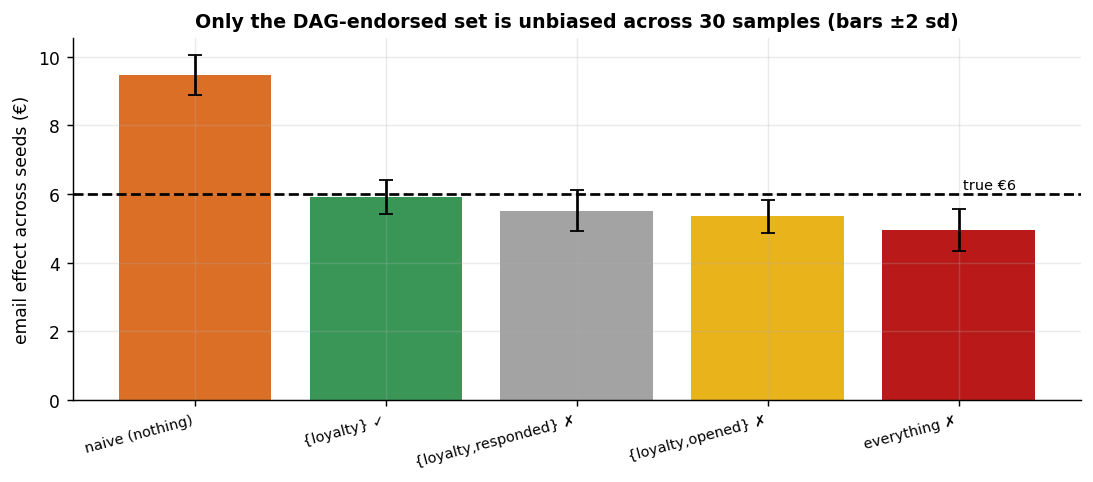

In [12]:
# --- Recovery across many seeds: which control sets are unbiased? (uncertainty on the bars) ---
NSEED = 12 if FAST else 30
allest = {k: [] for k in choices}
for sd in range(NSEED):
    ds, _tt = dgp.dag_control_demo(n=2000, seed=400 + sd)
    for k, v in choices.items():
        Xs = np.column_stack([np.ones(len(ds)), ds["email"].values] + [ds[c].values for c in v])
        allest[k].append(np.linalg.lstsq(Xs, ds["spend"].values, rcond=None)[0][1])
means = np.array([np.mean(allest[k]) for k in choices]); sds = np.array([np.std(allest[k]) for k in choices])
fig, ax = plt.subplots(figsize=(8.5, 3.8))
cols = [plots.ORANGE, plots.GREEN, plots.GREY, plots.GOLD, "#b30000"]
ax.bar(range(len(choices)), means, yerr=1.96 * sds, capsize=4, color=cols, alpha=0.9)
ax.axhline(true_ate, color="k", ls="--"); ax.text(4.3, true_ate + 0.15, f"true €{true_ate:.0f}", ha="right", fontsize=8)
ax.set_xticks(range(len(choices))); ax.set_xticklabels(list(choices.keys()), rotation=15, ha="right", fontsize=8)
ax.set_ylabel("email effect across seeds (€)"); ax.set_title(f"Only the DAG-endorsed set is unbiased across {NSEED} samples (bars ±2 sd)")
fig.tight_layout()
for k in choices:
    a = np.array(allest[k]); print(f"{k:26s} mean €{a.mean():5.2f}  bias {a.mean()-true_ate:+.2f}  sd {a.std():.2f}")
dag_key = next(k for k in choices if "✓" in k)
dag_bias = float(np.mean(allest[dag_key]) - true_ate)
print(f"\nThe DAG-endorsed set is centred on the truth (bias {dag_bias:+.2f} across {NSEED} seeds — sampling "
      "noise, not a fixed offset); the collider / over-control sets carry a PERSISTENT bias\n(a fixed offset "
      "that does NOT shrink across seeds, unlike sampling noise) — exactly what a single sample can hide.")

### 5c · "But we have millions of rows" — more data does not fix a bad control set

The bars above separate noise from bias at a single sample size; the print-out *claims* the wrong sets'
offsets would not shrink with more data. Make the claim formal: for control set $W$ the OLS estimate obeys

$$
\hat\tau_W \;\xrightarrow{\;p\;}\; \tau + b_W ,
$$

where $b_W$ is a **fixed asymptotic bias** determined only by identification — which backdoor paths $W$
leaves open (the naive set) or which collider paths it opens (the kitchen-sink set). As $n \to \infty$,
sampling noise vanishes but $b_W$ does not move an inch: **more data buys precision, never validity.** We
verify by sweeping the sample size for three control sets, many fresh samples per point:

naive (nothing)    error: n=500 → +3.45±0.73   n=8,000 → +3.47±0.21
{loyalty} ✓        error: n=500 → +0.01±0.45   n=8,000 → -0.05±0.15
everything ✗       error: n=500 → -1.02±0.52   n=8,000 → -1.00±0.17


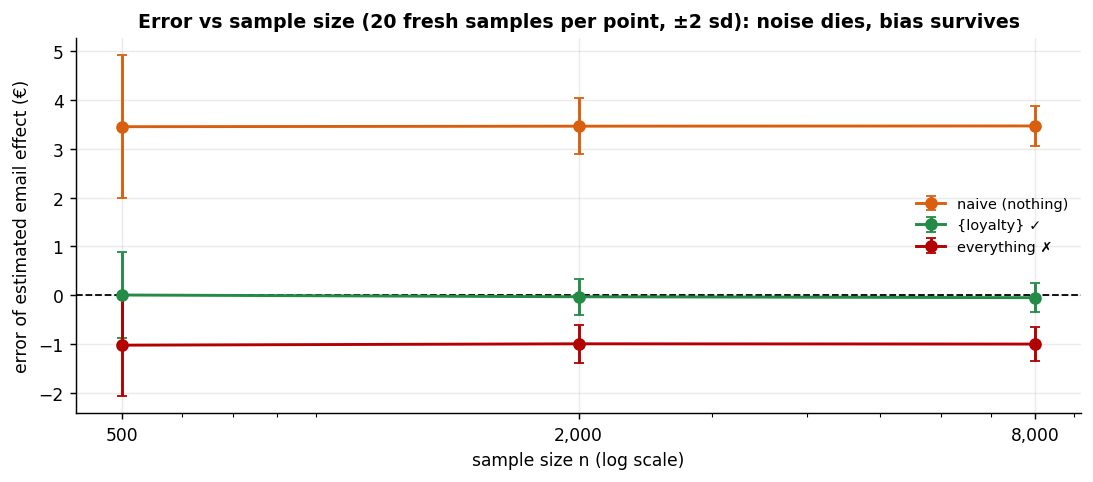

In [13]:
NS_N = 8 if FAST else 20
n_grid = [500, 2000, 8000]
sweep_sets = {"naive (nothing)": ([], plots.ORANGE), "{loyalty} ✓": (["loyalty"], plots.GREEN),
              "everything ✗": (["loyalty", "responded", "opened_email"], "#b30000")}
sweep_err = {lab: [[ols_on(dgp.dag_control_demo(n=nn, seed=700 + 37 * j)[0], ctrl) - true_ate
                    for j in range(NS_N)] for nn in n_grid]
             for lab, (ctrl, _c) in sweep_sets.items()}
fig, ax = plt.subplots(figsize=(8.5, 3.8))
for lab, (ctrl, col) in sweep_sets.items():
    e = np.array(sweep_err[lab])
    ax.errorbar(n_grid, e.mean(axis=1), yerr=2 * e.std(axis=1), marker="o", capsize=3, color=col, lw=1.6, label=lab)
ax.axhline(0, color="k", ls="--", lw=1)
ax.set_xscale("log"); ax.set_xticks(n_grid); ax.set_xticklabels([f"{n:,}" for n in n_grid])
ax.set_xlabel("sample size n (log scale)"); ax.set_ylabel("error of estimated email effect (€)")
ax.set_title(f"Error vs sample size ({NS_N} fresh samples per point, ±2 sd): noise dies, bias survives")
ax.legend(frameon=False, fontsize=8); fig.tight_layout()
for lab in sweep_sets:
    e = np.array(sweep_err[lab])
    print(f"{lab:18s} error: n=500 → {e[0].mean():+.2f}±{e[0].std():.2f}   n=8,000 → {e[2].mean():+.2f}±{e[2].std():.2f}")

**Read-out.** Every error bar narrows as $n$ grows — but only the green line narrows **around zero**. The
naive and kitchen-sink lines narrow around the wrong number: at $n = 8{,}000$ they are *more confidently
wrong* than at 500. This is the rebuttal to the pitch every CMO eventually hears — "our platform observes
millions of customers, so the numbers are rock-solid." Volume shrinks the error bars; if the adjustment set
is wrong, it shrinks them around the artifact. The first question for any vendor deck is not *how many
rows* but ***what did you control for — and what did that choice condition on?***

### 5x · Point estimate vs posterior — what the Bayesian layer buys, and what it cannot

Everything above was classical: one `cl.ols` call per adjustment set, five point estimates, five confidence
intervals. §4's Bayesian model — the `pathmc` fit that §6's sensitivity grid runs on — targets the **same
estimand** (`email`'s coefficient in the spend equation) under the **same adjustment set** ($Z =
\{\text{loyalty}\}$, because the declared spec says `spend ~ email + loyalty`) with **weak priors** and the
same 2,000 rows. So the two should agree, and if they do we should say so without flinching.

But agreement on the endorsed set is only half the account. This notebook's thesis is that identification,
not inference, is where the causal content lives — and §5's read-out *asserted* that a Bayesian refit on the
kitchen-sink controls "would hand you an interval that looks essentially as tight, centred on the biased
number." An assertion is not a demonstration. So the cell below fits **the same Bayesian machinery a second
time on the wrong adjustment set** — spend on email plus loyalty *plus the collider and the descendant* —
with the same priors and the same sampler, and reports its posterior and its decision probability alongside
the others. Three columns, one estimand, and the only difference that matters is $Z$.

In [14]:
# --- 5x · classical OLS vs Bayesian posterior, on the SAME adjustment set — and then on the WRONG one ---
idata = m.fit(random_seed=SEED, progressbar=False, **FIT)     # the DAG-endorsed model: spend ~ email + loyalty
tau_draws = idata.posterior["beta_spend"].sel(spend_predictors="email").values.ravel()

def hdi94(x, prob=0.94):                      # shortest interval holding `prob` of the posterior mass
    xs = np.sort(np.asarray(x)); n_ = len(xs); k = int(np.floor(prob * n_))
    i = int(np.argmin(xs[k:] - xs[:n_ - k]))
    return float(xs[i]), float(xs[i + k])

lo94, hi94 = hdi94(tau_draws)
COST = 5.0                                    # fully-loaded € per targeted contact — the break-even §6 decides against
p_pos, p_cost = float((tau_draws > 0).mean()), float((tau_draws > COST).mean())

# The SAME machinery — same priors, same sampler, same data — pointed at the KITCHEN-SINK adjustment set.
KS = ["email", "loyalty", "responded", "opened_email"]
with pymc.Model(coords={"ctrl": KS}) as ks_model:
    b_ks = pymc.Normal("beta", 0.0, 10.0, dims="ctrl")       # weak, uninformative — no prior is doing any work
    a_ks = pymc.Normal("alpha", 20.0, 20.0)
    s_ks = pymc.HalfNormal("sigma", 10.0)
    pymc.Normal("y", a_ks + pymc.math.dot(df[KS].to_numpy(float), b_ks), s_ks, observed=df["spend"].to_numpy(float))
    ks_idata = pymc.sample(**FIT, cores=FIT["chains"], random_seed=SEED, progressbar=False)
tau_ks = ks_idata.posterior["beta"].sel(ctrl="email").values.ravel()
ks_lo, ks_hi = hdi94(tau_ks)
p_cost_ks = float((tau_ks > COST).mean())

# apples to apples: a 94% confidence interval, so the classical width is compared at the posterior's level
adj94 = cl.ols(df, F_ADJ, target="email", cov="HC1", alpha=0.06)
gap = tau_draws.mean() - adj_cl.estimate

def row(arm, zset, e, lo_, hi_):
    print(f"  {arm:<26}{zset:<22}{e:>5.2f} [{lo_:5.2f},{hi_:5.2f}]{hi_ - lo_:>6.2f}")

print(f"  {'arm':<26}{'adjustment set Z':<22}{'€':>5} {'94% interval':<13}{'width':>6}")
row("classical OLS (94% CI)", "{loyalty} — endorsed", adj94.estimate, adj94.ci[0], adj94.ci[1])
row("Bayes posterior (94% HDI)", "{loyalty} — endorsed", float(tau_draws.mean()), lo94, hi94)
row("Bayes posterior (94% HDI)", "everything — WRONG", float(tau_ks.mean()), ks_lo, ks_hi)

both_in = (lo94 <= true_ate <= hi94) and (adj94.ci[0] <= true_ate <= adj94.ci[1])
print(f"\nZ = {{loyalty}}: the two arms differ by €{abs(gap):.3f} on the point estimate")
print(f"  ({abs(gap) / adj_cl.se:.2f} classical SEs), and their intervals differ in width by "
      f"€{abs((hi94 - lo94) - (adj94.ci[1] - adj94.ci[0])):.3f}.")
print(f"  The truth (€{true_ate:.0f}) is inside {'BOTH' if both_in else 'NOT both'}.")
print(f"Z = everything: the posterior sits €{tau_ks.mean() - true_ate:+.2f} from the truth, which")
print(f"  falls {'INSIDE' if ks_lo <= true_ate <= ks_hi else 'OUTSIDE'} its 94% HDI — and it is "
      f"just as tight (€{ks_hi - ks_lo:.2f} vs €{hi94 - lo94:.2f} wide).")
print(f"  Nothing in the output announces the bias.")

print(f"\nTHE DECISION QUANTITY — what no confidence interval can produce: P(τ > €{COST:.0f})")
print(f"  Bayes, Z = {{loyalty}}  (right) : P(τ>0)={p_pos:.3f} · P(τ>cost)={p_cost:.3f}"
      f" -> {'GO' if p_cost > 0.9 else 'NO-GO'}")
print(f"  Bayes, Z = everything (WRONG) : P(τ>0)={float((tau_ks > 0).mean()):.3f} · "
      f"P(τ>cost)={p_cost_ks:.3f} -> {'GO' if p_cost_ks > 0.9 else 'NO-GO'}")
print(f"  classical, either set         : does not exist — a CI is not a")
print(f"                                  probability about τ.")
print(f"\nkitchen-sink convergence: {est.convergence_report(ks_idata)['summary']}")

  arm                       adjustment set Z          € 94% interval  width
  classical OLS (94% CI)    {loyalty} — endorsed   6.09 [ 5.63, 6.54]  0.91
  Bayes posterior (94% HDI) {loyalty} — endorsed   6.09 [ 5.66, 6.57]  0.90
  Bayes posterior (94% HDI) everything — WRONG     4.97 [ 4.49, 5.44]  0.96

Z = {loyalty}: the two arms differ by €0.006 on the point estimate
  (0.03 classical SEs), and their intervals differ in width by €0.005.
  The truth (€6) is inside BOTH.
Z = everything: the posterior sits €-1.03 from the truth, which
  falls OUTSIDE its 94% HDI — and it is just as tight (€0.96 vs €0.90 wide).
  Nothing in the output announces the bias.

THE DECISION QUANTITY — what no confidence interval can produce: P(τ > €5)
  Bayes, Z = {loyalty}  (right) : P(τ>0)=1.000 · P(τ>cost)=1.000 -> GO
  Bayes, Z = everything (WRONG) : P(τ>0)=1.000 · P(τ>cost)=0.448 -> NO-GO
  classical, either set         : does not exist — a CI is not a
                                  probability about τ

**The honest verdict — three beats, in the order they matter.**

**1 · On the endorsed set, they agree. Say it plainly.** The classical OLS estimate and the Bayesian
posterior mean differ by a rounding error — a fraction of one standard error, as the print-out quantifies —
and the 94% credible interval is, to within a couple of cents, the 94% confidence interval. That is not a
disappointment; it is the point. With 2,000 rows and priors this weak, the posterior *is* the likelihood, and
the likelihood *is* the least-squares fit. **The Bayesian layer did not move the number, because the number
was never where the difficulty lay.** Anyone who arrived hoping that "going Bayesian" would improve the
estimate has just been shown, on their own data, that it does not.

**2 · What the posterior does buy — precisely one thing here, and it is the thing the business asked for.**
Look at the last block: $P(\tau > \text{cost})$. §6 and §7 run the campaign decision on
$P(\text{lift} > \text{cost}) \ge 0.9$, and that is a probability **about the effect**, natively a posterior
quantity. The classical arm cannot produce it — not with a tighter CI, not with a bootstrap (which
approximates the *sampling distribution of the estimator*, not a distribution of belief over $\tau$), not
with a p-value. There is no number to compare against the 0.9 bar; the row is empty by construction. That
single column is the whole earned payoff of the Bayesian machinery in this notebook, and it is a real one:
it turns "the point estimate beats €5" into a stated risk of being wrong.

Be equally precise about what does *not* belong in that column. §6's **γ·δ sensitivity contour** and the
**E-value** are arithmetic on the *observed ATE* — `adjusted_ATE = observed_ATE − γ·δ`, and
$\text{RR} \approx \exp(0.91 d)$ — and would run identically off the classical point estimate. They are
sensitivity analysis, not Bayesian inference. Crediting them to the posterior would be padding the bill.

**3 · What Bayes did NOT buy — and this is the notebook's thesis, now demonstrated rather than asserted.**
The third row of the table is the same Bayesian machinery — a PyMC linear model with priors as weak as
`pathmc`'s, sampled by the same NUTS, on the same 2,000 rows — pointed at the kitchen-sink adjustment set.
Its posterior is **tight, well-mixed, convergent (r-hat and ESS are printed, and they are immaculate), and
centred on the wrong number**; the truth falls outside its 94% HDI; its credible interval is essentially as tight as the correct
model's (€0.96 vs €0.90 — the extra six cents buys you nothing); and it emits a perfectly well-formed
decision probability
$P(\tau > \text{cost})$ — which, being computed about a biased estimand, points at the *opposite decision*
from the correct model. Read the two GO/NO-GO verdicts side by side: same machinery, same data, same rule,
opposite call. Nothing in the diagnostics complains, because **nothing is wrong with the inference** — the
inference is faithfully reporting the posterior of a quantity that is not the causal effect.

A collider is a collider under any inference paradigm. Priors do not close backdoor paths; posteriors do not
detect open ones; MCMC converges just as happily on a biased estimand as on an unbiased one, and reports its
uncertainty just as confidently. **Bayes buys you a decision quantity; it does not buy you identification.**
Identification came from the DAG in §3, and if the DAG is wrong — as §5's falsification test showed it can
be — then the posterior inherits the error and dresses it in a credible interval. That is why this notebook,
alone in the cookbook, spends its length on a graph instead of a model.

## 6 · Decide, in euros — the stakes of the control choice, with a robustness statement

Two parts. **(a) The euro stakes.** Getting the control set wrong isn't academic: budgeting a campaign on the
naive (confounded) estimate books *phantom* incremental revenue, which we price out below across a realistic
campaign — the concrete cost of skipping the DAG. **(b) The robustness statement.** Identification is
untestable, so we bound the residual risk: how strong would an *unobserved* confounder have to be to overturn
the conclusion? `pathmc.sensitivity` and the E-value are **two independent parameterizations (two different ways of dialing the same knob) of the same worry**, not one
summarising the other. The first is an **additive γ·δ contour in raw € units**: it sweeps a hidden confounder's
treatment- and outcome-associations (γ, δ) and maps where the adjusted effect `observed_ATE − γ·δ` tips through
zero — i.e. where **γ·δ ≈ the observed ATE** (the grid is widened so that zero-crossing is actually reachable).
The second is VanderWeele's **E-value**, a single number on the **risk-ratio scale**: for a continuous euro
outcome the effect is first standardized (rescaled into standard-deviation units — the code below prints the
d it uses) and mapped to an approximate risk ratio via
RR ≈ exp(0.91·d), and the E-value reports how strong the confounder's risk-ratio associations would have to be.
Because the two live on **different scales** (raw € vs risk ratio), the E-value does *not* summarise the γ·δ
contour, and the euro effect must *not* be plotted on the E-value's axis.

And because the fit is Bayesian, a third part follows the code: we take the posterior **5x** already
sampled and restate the GO/NO-GO as a probability instead of a point comparison. (Both the fit and the €5
break-even `COST` were set in 5x; §6 spends them.)

Observed adjusted ATE €6.09 (true €6.0)  ·  standardized d = 0.73 sd (spend sd €8.33)  ·  E-value ≈ 3.30
An unmeasured confounder would need ~3.3× association (risk-ratio scale) with BOTH email and
spend to explain the effect away — ask the domain expert whether anything that strong is plausible.

Euro stakes: budgeting on the naive €9.45 instead of the DAG-endorsed €6.09 overstates incremental
revenue by €168,031 across a 50,000-customer campaign — phantom lift that would justify overspending on the email.

Break-even €5.00/email · E-value vs break-even ≈ 1.50 (how strong a hidden confounder must be to drag the DAG-endorsed effect below cost).
  naive (nothing)            € 9.45  ->  GO   (lift > cost)
  {loyalty} ✓                € 6.09  ->  GO   (lift > cost)
  {loyalty,responded} ✗      € 5.58  ->  GO   (lift > cost)
  {loyalty,opened} ✗         € 5.45  ->  GO   (lift > cost)
  everything ✗               € 4.97  ->  NO-GO (lift ≤ cost)
Same data, 1/5 control sets fall below the €5.

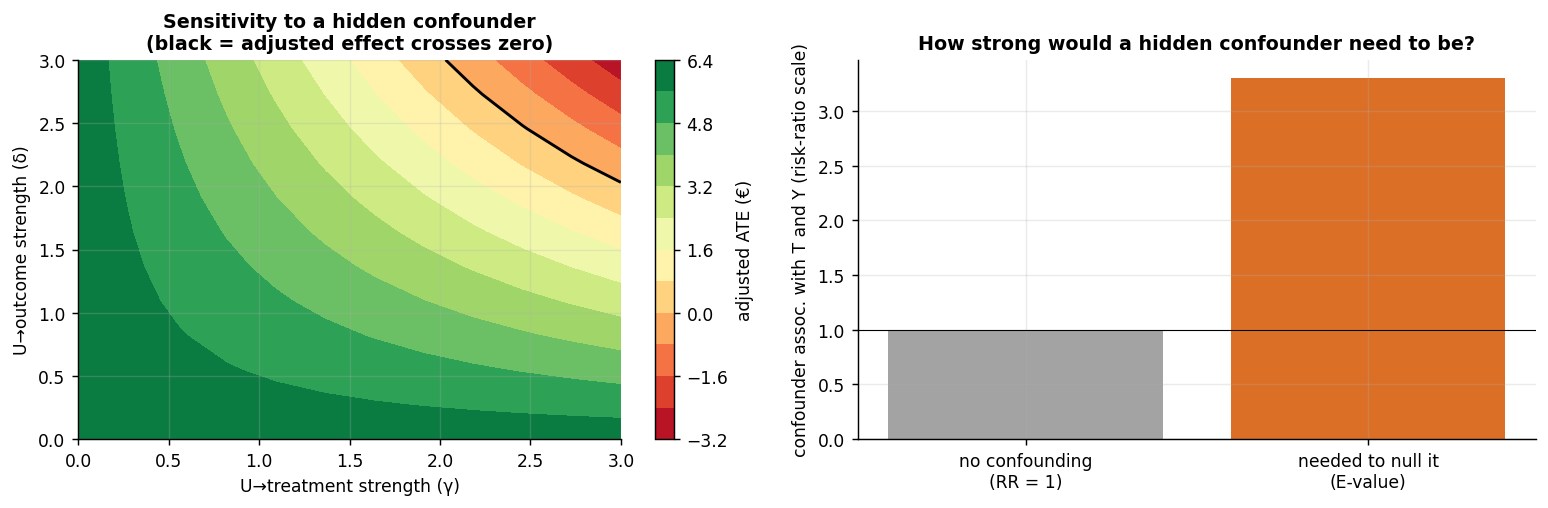

In [15]:
# (the DAG-endorsed posterior `idata` and the €5 break-even `COST` were both set in 5x above)
# pathmc's bias model is adjusted_ATE = observed_ATE - gamma*delta, so the grid must reach
# gamma*delta ~ the observed effect for a "crosses zero" line to exist. The default (0,1)^2 caps
# the bias at 1 (< the €6 effect) and can NEVER cross zero — we widen the ranges to (0,3)^2.
sens = m.sensitivity("spend", "email", n_grid=12, gamma_range=(0.0, 3.0), delta_range=(0.0, 3.0))
adj = np.asarray(sens.adjusted_ate_mean); COSTLINE = 0.0
# The E-value standardizes first: d = |observed ATE - threshold| / sd(outcome), then RR ≈ exp(0.91·d).
# Print the d it actually uses, so no prose has to hard-code a number that would drift silently.
spend_sd = float(df["spend"].std())
evalue = metrics.e_value(float(sens.observed_ate), cost=COSTLINE, sd=spend_sd)
d_std = abs(float(sens.observed_ate) - COSTLINE) / spend_sd
print(f"Observed adjusted ATE €{float(sens.observed_ate):.2f} (true €{true_ate:.1f})  ·  standardized "
      f"d = {d_std:.2f} sd (spend sd €{spend_sd:.2f})  ·  E-value ≈ {evalue:.2f}")

g, d = np.meshgrid(sens.gamma_values, sens.delta_values, indexing="ij")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
cs = ax[0].contourf(g, d, adj, levels=12, cmap="RdYlGn"); ax[0].contour(g, d, adj, levels=[0], colors="k", linewidths=1.6)
plt.colorbar(cs, ax=ax[0], label="adjusted ATE (€)")
ax[0].set_xlabel("U→treatment strength (γ)"); ax[0].set_ylabel("U→outcome strength (δ)")
ax[0].set_title("Sensitivity to a hidden confounder\n(black = adjusted effect crosses zero)")
# E-value on the RISK-RATIO scale only — the euro effect does NOT belong on this axis.
ax[1].bar(["no confounding\n(RR = 1)", "needed to null it\n(E-value)"], [1.0, evalue],
          color=[plots.GREY, plots.ORANGE], alpha=0.9); ax[1].axhline(1.0, color="k", lw=0.6)
ax[1].set_ylabel("confounder assoc. with T and Y (risk-ratio scale)")
ax[1].set_title("How strong would a hidden confounder need to be?")
fig.tight_layout()
print(f"An unmeasured confounder would need ~{evalue:.1f}× association (risk-ratio scale) with BOTH email and\n"
      f"spend to explain the effect away — ask the domain expert whether anything that strong is plausible.")

# The euro stakes of the control choice: budgeting on the naive (confounded) estimate books phantom lift.
CAMPAIGN_N = 50_000
naive_ate, correct_ate = ests["naive (nothing)"], ests["{loyalty} ✓"]
overstatement = (naive_ate - correct_ate) * CAMPAIGN_N
print(f"\nEuro stakes: budgeting on the naive €{naive_ate:.2f} instead of the DAG-endorsed €{correct_ate:.2f} "
      f"overstates incremental\nrevenue by €{overstatement:,.0f} across a {CAMPAIGN_N:,}-customer campaign — "
      f"phantom lift that would justify overspending on the email.")

# Business break-even: a plausible per-email cost turns each ATE into a go/no-go, and shows which control
# choice would FLIP the campaign decision. The E-value is now measured against break-even (not zero).
evalue_be = metrics.e_value(float(sens.observed_ate), cost=COST, sd=float(df["spend"].std()))
print(f"\nBreak-even €{COST:.2f}/email · E-value vs break-even ≈ {evalue_be:.2f} "
      f"(how strong a hidden confounder must be to drag the DAG-endorsed effect below cost).")
for k, v in ests.items():
    verdict = "GO   (lift > cost)" if v > COST else "NO-GO (lift ≤ cost)"
    print(f"  {k:26s} €{v:5.2f}  ->  {verdict}")
n_below = sum(v <= COST for v in ests.values())
print(f"Same data, {n_below}/{len(ests)} control sets fall below the €{COST:.2f} break-even: over-controlling drags "
      f"the true €{true_ate:.1f}\neffect below cost, so the kitchen-sink set would wrongly KILL a campaign the "
      f"DAG-endorsed {{loyalty}} set green-lights — the control choice is a business call, not a technicality.")
print(f"control model convergence: {est.convergence_report(idata)["summary"]}")


### The Bayesian read — how sure are we, and of what?

Every GO/NO-GO in the table above compared a *point estimate* to the €5 break-even — thin ice for a
Bayesian cookbook. The `m.fit(...)` in 5x, which also powered the sensitivity grid, is a full posterior over
every structural coefficient, so we already own the entire distribution of the email effect **under the
endorsed set $\{loyalty\}$**. The honest decision statement replaces "point estimate > €5" with the two
probabilities 5x printed: $P(\tau > 0)$ — is there any effect — and $P(\tau > \text{cost})$ — does it pay.
Here we plot the distribution behind them.

**On the convergence line printed above** (`control model convergence: max r-hat … · min ESS … · divergences …`): **R-hat** near 1.00 means the independent sampler chains agree (**≤ 1.01 passes**); **ESS** (effective sample size) is the number of *independent* posterior draws behind each estimate (a few hundred is plenty here); **0 divergences** means the sampler hit no numerical pathologies. Under the FAST profile the short chains can nudge R-hat to ~1.02 and trigger a benign "problems during sampling" notice that clears in a FULL run.

posterior mean €6.09   ·   94% HDI [€5.66, €6.57]   ·   classical OLS (HC1) €6.09 [€5.69, €6.48]
P(τ > 0) = 1.000   ·   P(τ > €5 break-even) = 1.000
Decision, restated honestly: GO with P(lift > cost) = 1.00 under the DAG-endorsed adjustment set — a probability, not a point comparison.


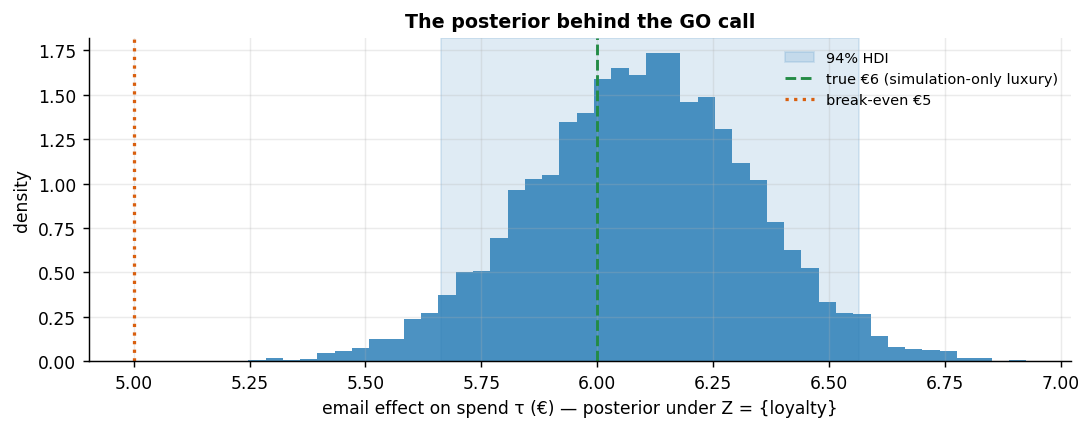

In [16]:
# tau_draws, hdi94, lo94/hi94, p_pos, p_cost all come from 5x — this cell only visualises the decision.
fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.hist(tau_draws, bins=45, color=plots.BLUE, alpha=0.85, density=True)
ax.axvspan(lo94, hi94, color=plots.BLUE, alpha=0.15, label="94% HDI")
ax.axvline(true_ate, color=plots.GREEN, ls="--", lw=1.6, label=f"true €{true_ate:.0f} (simulation-only luxury)")
ax.axvline(COST, color=plots.ORANGE, ls=":", lw=1.8, label=f"break-even €{COST:.0f}")
ax.set_xlabel("email effect on spend τ (€) — posterior under Z = {loyalty}"); ax.set_ylabel("density")
ax.set_title("The posterior behind the GO call")
ax.legend(frameon=False, fontsize=8); fig.tight_layout()
print(f"posterior mean €{tau_draws.mean():.2f}   ·   94% HDI [€{lo94:.2f}, €{hi94:.2f}]"
      f"   ·   classical OLS (HC1) €{adj_cl.estimate:.2f} [€{adj_cl.ci[0]:.2f}, €{adj_cl.ci[1]:.2f}]")
print(f"P(τ > 0) = {p_pos:.3f}   ·   P(τ > €{COST:.0f} break-even) = {p_cost:.3f}")
print(f"Decision, restated honestly: GO with P(lift > cost) = {p_cost:.2f} under the DAG-endorsed adjustment set "
      "— a probability, not a point comparison.")

**Read-out.** Identification (Steps 3–5) chose *which* number the posterior concentrates on; the posterior
says *how sure* to be of that number. Here the whole 94% HDI sits above the €5 break-even, so
$P(\text{lift} > \text{cost})$ prints at essentially 1 and the GO is not riding a knife's edge — if the HDI
straddled the cost line, the same plot would say "test before you spend" (nb01's straddler logic). One
warning label, and it matters: **this width is honest only under the endorsed adjustment set.** 5x refitted
this same machinery on the kitchen-sink controls and it handed back an interval essentially as tight (the
printed widths differ by six cents) — centred on the biased number, with a decision probability that flips
the call. A tight posterior around a
collider-biased point is *confidently wrong*: precision quantifies sampling noise, never identification
error. That is §4's "the model can't tell you it's biased," now in Bayesian dress.

## 6b · The stakes on **real** data (LaLonde) — good vs bad adjustment

This isn't an academic worry, and it isn't confined to toy graphs. The famous **LaLonde (1986) /
Dehejia–Wahba** job-training data pairs a randomized experiment — benchmark effect on 1978 earnings
≈ \$1,800 — with an observational comparison group drawn from population surveys, so observational
adjustment choices can be *scored* against an experimental answer. The cell below prints three reads of the
same observational data:

- **naive** (no controls) — the trainees were far poorer than the survey comparison group before the
  program existed, so the raw gap is dominated by selection;
- **bad adjustment** — demographics only (age, education, race, marital status, degree), *dropping* the two
  pre-program earnings years `re74`/`re75`. It looks responsible — six pre-treatment covariates! — but
  Dehejia & Wahba's core finding is that the pre-earnings variables are the **load-bearing confounders**;
- **good adjustment** — the same regression *plus* `re74`/`re75`, the full standard pre-treatment set.

The data is fetched from a public URL (you provide nothing) and the section is gated on `CMP_REAL=1` so
offline runs skip it; the committed notebook ships with the gated branch **executed**, and the read-out
below refers to those printed numbers.

In [17]:
if os.environ.get("CMP_REAL") == "1":
    from cmp import data
    ll = data.load_lalonde()
    T2, Y2 = ll["treat"].values, ll["re78"].values
    good = ["age", "educ", "black", "hispan", "married", "nodegree", "re74", "re75"]  # + pre-program earnings
    bad = ["age", "educ", "black", "hispan", "married", "nodegree"]                   # demographics only
    def lalonde_adj(cols):
        D = np.column_stack([np.ones(len(ll)), T2, ll[cols].values])
        return np.linalg.lstsq(D, Y2, rcond=None)[0][1]
    naive2 = Y2[T2 == 1].mean() - Y2[T2 == 0].mean()
    print("Effect of job training on 1978 earnings (observational comparison group, n="
          f"{len(ll)}):")
    print(f"  naive — no controls                        : ${naive2:>7,.0f}")
    print(f"  BAD adjust — demographics, NO re74/re75    : ${lalonde_adj(bad):>7,.0f}")
    print(f"  GOOD adjust — demographics + re74/re75     : ${lalonde_adj(good):>7,.0f}")
    print(f"  experimental benchmark (RCT reference)     : ≈ $1,800")
    print(f"why the naive fails: 1974 earnings were ${ll.loc[ll.treat == 1, 're74'].mean():,.0f} (future trainees) vs "
          f"${ll.loc[ll.treat == 0, 're74'].mean():,.0f} (comparison group) — the groups were never comparable.")
else:
    print("Real-data section skipped. Set CMP_REAL=1 and re-run to fetch the LaLonde dataset.")

Effect of job training on 1978 earnings (observational comparison group, n=614):
  naive — no controls                        : $   -635
  BAD adjust — demographics, NO re74/re75    : $  1,164
  GOOD adjust — demographics + re74/re75     : $  1,548
  experimental benchmark (RCT reference)     : ≈ $1,800
why the naive fails: 1974 earnings were $2,096 (future trainees) vs $5,619 (comparison group) — the groups were never comparable.


**Read-out (gated run).** The naive comparison does not merely miss the benchmark — on this composite it
comes out **negative**, "training *reduced* earnings," because the comparison group out-earned the trainees
years before the program existed (the last printed line quantifies the pre-program gap). Adjusting for
demographics alone repairs the sign but still lands well short of the good specification; restoring the two
pre-program earnings years moves the estimate within a few hundred dollars of the ≈ \$1,800 experimental
answer. Same data, three defensible-*sounding* specifications, three different stories — and choosing among
them is exactly the §3 skill: prior earnings are the strongest plausible common cause of *enrolling in the
program* and *earning later*, so the backdoor criterion demands them in $Z$. Dropping a load-bearing
confounder is the mirror image of adding a collider: both are identification failures no estimator or
sample size repairs (§5c). *(If you re-executed this notebook without `CMP_REAL=1`, the numbers referenced
here are in the committed output; re-run the gated branch before quoting them elsewhere.)*

## 7 · From the toy graph to your CRM — a practitioner's covariate checklist

The intro promised to tell you which columns of *your* campaign table belong in the model. The toy
variables map one-to-one onto the fields every marketing dataset carries:

| variable (as measured) | likely causal role | action |
|---|---|---|
| loyalty tier, RFM score computed **before** send, region, seasonality, prior-quarter spend | confounder — drives both targeting and spend | **control** |
| opens, clicks, site visits **after** the send | mediator — or hidden collider via latent engagement (§4's `opened_email`) | **exclude** when the question is the total effect |
| responded / converted / unsubscribed | collider (post-outcome) | **exclude — and never filter on it** (§4b) |
| survey participation, post-campaign app install | selection collider | **exclude**; distrust any panel filtered on them |
| pre-treatment *proxy* of an unmeasured trait (e.g. historical open-rate, coupon history) | it depends — draw the graph | M-bias risk if it is a common effect of latents (§1c) |

Pocket rule: **pre-treatment AND a plausible common cause of $T$ and $Y$ ⇒ in; caused by $T$ ⇒ out;
anything else ⇒ draw the DAG.** A timestamp is a heuristic; the graph is the criterion — and when in doubt
between "possible confounder" and "possible M-collider," §1c's magnitude argument says adjusting is usually
the lesser evil.

### The one-paragraph decision

> We estimate the email's effect on spend adjusting for **`{loyalty}` only** — the set the backdoor
> criterion selects and the only candidate that survives falsification against the data
> (`opened_email` fails its implied-independence test, so it stays out even though the *declared* graph
> green-lit it). Under that set the effect is ≈ €6 with the 94% HDI printed above, clearing the €5
> break-even with $P(\text{lift} > \text{cost}) \approx 1$: **GO**. Robustness: a hidden confounder would
> need roughly a 3× risk-ratio association with *both* treatment and outcome to null the effect, and about
> 1.5× to drag it below break-even — the second number is the one to debate with the domain expert. The
> control choice is not a technicality: budgeting on the naive read books ≈ €170k of phantom revenue on a
> 50,000-customer campaign, and the kitchen-sink set flips this true-GO campaign to NO-GO. Residual risk is
> the graph itself, so the follow-up is not a bigger model — it is re-running `test_implications` on each
> quarter's fresh data and re-drawing the DAG the moment the data rejects an implication. Note what does
> *not* appear in this memo as a safeguard: the estimator. Plain OLS on the endorsed set (Step 0) and the
> Bayesian posterior (5x) return the same number to the cent; the posterior earns its place only by
> producing $P(\text{lift} > \text{cost})$, and 5x showed that the very same posterior, run on the
> kitchen-sink controls, would have reported that probability just as confidently for the wrong estimand.

In [18]:
import json
decision = {
    "adjustment_set": ["loyalty"],
    "ate_hat_classical_ols_hc1": [round(adj_cl.estimate, 2), [round(adj_cl.ci[0], 2), round(adj_cl.ci[1], 2)]],
    "ate_hat_posterior_mean": round(float(tau_draws.mean()), 2),
    "hdi94": [round(lo94, 2), round(hi94, 2)],
    "p_gt_zero": round(p_pos, 3),
    "p_gt_cost": round(p_cost, 3),
    "e_value_null": round(float(evalue), 2),
    "e_value_breakeven": round(float(evalue_be), 2),
    "phantom_revenue_naive_eur": round(float(overstatement)),
    "decision_flipping_sets": [k for k, v in ests.items() if (v > COST) != (ests["{loyalty} ✓"] > COST)],
    "p_gt_cost_if_kitchen_sink_controls": round(p_cost_ks, 3),   # same machinery, wrong Z — the decision flips
    "dag_falsification": {"n_tests": int(falsif.n_tests), "n_violations": int(falsif.n_violations)},
}
print(json.dumps(decision, indent=2, ensure_ascii=False))

{
  "adjustment_set": [
    "loyalty"
  ],
  "ate_hat_classical_ols_hc1": [
    6.09,
    [
      5.69,
      6.48
    ]
  ],
  "ate_hat_posterior_mean": 6.09,
  "hdi94": [
    5.66,
    6.57
  ],
  "p_gt_zero": 1.0,
  "p_gt_cost": 1.0,
  "e_value_null": 3.3,
  "e_value_breakeven": 1.5,
  "phantom_revenue_naive_eur": 168031,
  "decision_flipping_sets": [
    "everything ✗"
  ],
  "p_gt_cost_if_kitchen_sink_controls": 0.448,
  "dag_falsification": {
    "n_tests": 4,
    "n_violations": 1
  }
}


## 8 · Caveats

- **The graph is an assumption.** `pathmc` gives the correct set *for the DAG you drew*. A missing
  or reversed edge changes the advice — the DAG must encode defensible domain knowledge.
- **Colliders hide in "obvious" controls.** "engaged", "responded", "opened", "clicked" are almost
  always post-treatment; excluding them feels wrong to practitioners and is exactly right.
- **Front-door as a fallback.** If a T–Y confounder is genuinely unmeasured but a fully-mediating
  measured variable exists, the front-door adjustment can still identify the effect — a tool to
  keep in reserve (notebook 04 builds the mediation machinery front-door leans on; full front-door
  identification needs assumptions beyond nb04's scope).
- **Sensitivity ≠ proof.** A high E-value means "robust to plausible hidden confounding," not
  "unconfounded." Pair it with the expert's judgement about what could be missing.
